# День 8 — PCA и кластеризация оптовых клиентов

**Датасет:** `Wholesale customers data.csv` — 440 клиентов оптового дистрибьютора.
Годовые траты (денежные единицы) по 6 категориям товаров: `Fresh, Milk, Grocery,
Frozen, Detergents_Paper, Delicassen`. Плюс два категориальных признака:
`Channel` (1 = HoReCa / отели-рестораны-кафе, 2 = Retail / розница) и
`Region` (Lisbon, Oporto, Other).

Сегменты интерпретируются как **«HoReCa против ритейла»**. PCA нужен, чтобы увидеть
шестимерные траты на плоскости.

---
## Шаг 1. EDA и подготовка
Смотрим на данные раньше, чем на модели: размер, масштабы, пропуски, выбросы,
распределения и корреляции. Затем приводим к одному масштабу через `StandardScaler`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

df = pd.read_csv("Wholesale customers data.csv")
print("Shape:", df.shape)
df.head()

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 1.1 Размер, типы, пропуски
Сколько объектов и признаков, какие типы, есть ли пропуски.

In [2]:
print("Объектов (строк):", df.shape[0])
print("Признаков (столбцов):", df.shape[1])
print()
df.info()
print()
print("Пропусков всего:", df.isna().sum().sum())
print("Полных дубликатов строк:", df.duplicated().sum())

Объектов (строк): 440
Признаков (столбцов): 8

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Пропусков всего: 0
Полных дубликатов строк: 0


6 категорий трат — числовые непрерывные признаки. `Channel` и `Region` —
категориальные коды, в PCA/кластеризацию по тратам их не включаем (используем
позже только как «правильный ответ» для проверки сегментов).

In [3]:
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

print("Распределение по Channel (1=HoReCa, 2=Retail):")
print(df["Channel"].value_counts().sort_index())
print("\nРаспределение по Region (1=Lisbon, 2=Oporto, 3=Other):")
print(df["Region"].value_counts().sort_index())

Распределение по Channel (1=HoReCa, 2=Retail):
Channel
1    298
2    142
Name: count, dtype: int64

Распределение по Region (1=Lisbon, 2=Oporto, 3=Other):
Region
1     77
2     47
3    316
Name: count, dtype: int64


### 1.2 Масштабы признаков
Главное, ради чего нужен `StandardScaler`: посмотрим, насколько различаются
диапазоны и средние значения категорий.

In [4]:
desc = df[spend_cols].describe().T
desc["range"] = desc["max"] - desc["min"]
desc[["mean", "std", "min", "max", "range"]]

,mean,std,min,max,range
Fresh,"12,000.3","12,647.3",3.0,"112,151.0","112,148.0"
Milk,"5,796.3","7,380.4",55.0,"73,498.0","73,443.0"
Grocery,"7,951.3","9,503.2",3.0,"92,780.0","92,777.0"
Frozen,"3,071.9","4,854.7",25.0,"60,869.0","60,844.0"
Detergents_Paper,"2,881.5","4,767.9",3.0,"40,827.0","40,824.0"
Delicassen,"1,524.9","2,820.1",3.0,"47,943.0","47,940.0"


In [5]:
# Во сколько раз средние/максимумы различаются между категориями
means = df[spend_cols].mean()
print("Отношение самого большого среднего к самому малому: "
      f"{means.max()/means.min():.1f}x  "
      f"({means.idxmax()} vs {means.idxmin()})")
print(f"Самый большой max ({df[spend_cols].max().idxmax()}): "
      f"{df[spend_cols].max().max():,.0f}")

Отношение самого большого среднего к самому малому: 7.9x  (Fresh vs Delicassen)
Самый большой max (Fresh): 112,151


**Вывод по масштабам:** средние трат различаются в разы (`Fresh` ~ в 10+ раз
больше `Delicassen`), а отдельные клиенты тратят на `Fresh`/`Grocery` десятки и
сотни тысяч. Без масштабирования `Fresh` и `Grocery` перетянут на себя и
расстояния в кластеризации, и дисперсию в PCA.

### 1.3 Распределения признаков
Гистограммы шести категорий.

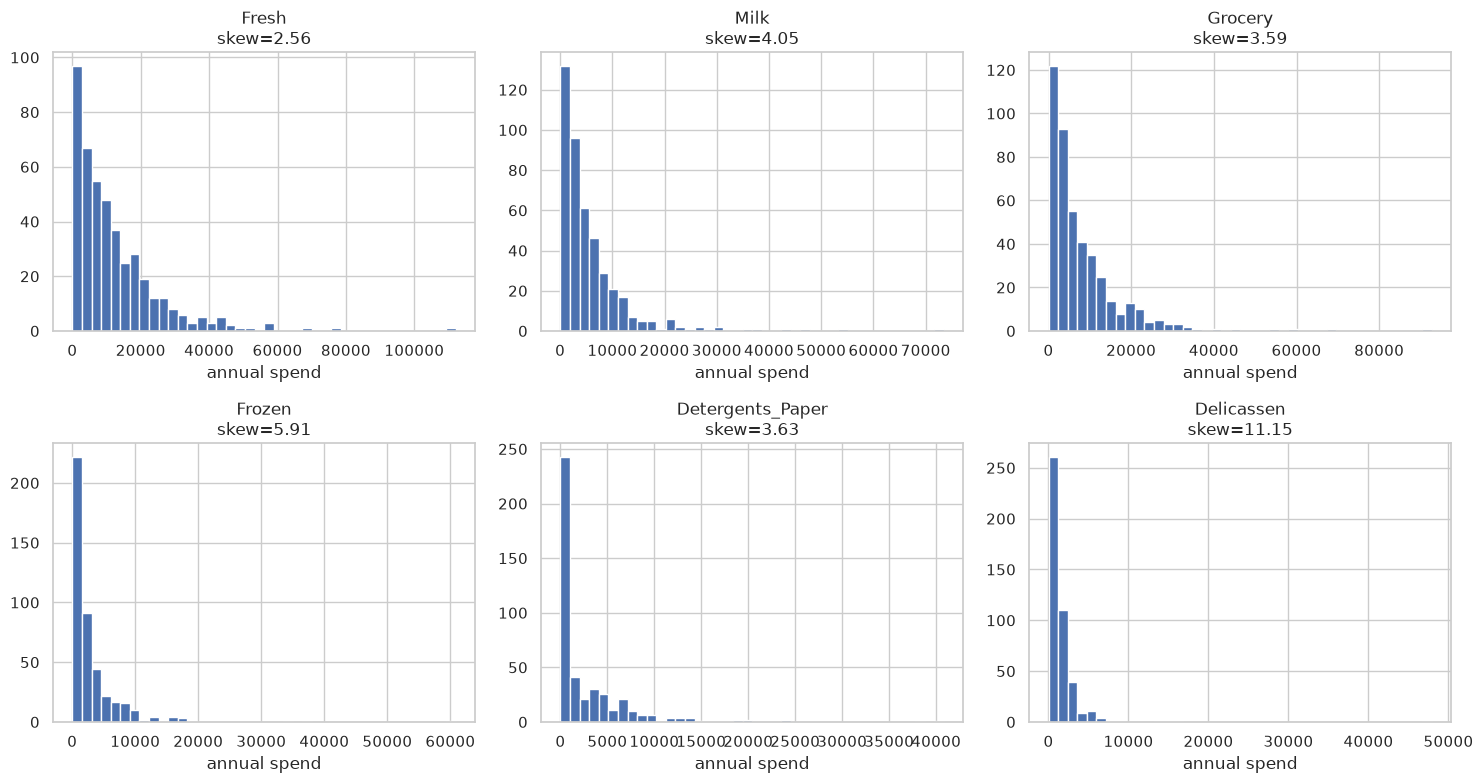

Коэффициент асимметрии (skewness):
Delicassen         11.2
Frozen              5.9
Milk                4.1
Detergents_Paper    3.6
Grocery             3.6
Fresh               2.6
dtype: float64


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), spend_cols):
    ax.hist(df[col], bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}\nskew={df[col].skew():.2f}")
    ax.set_xlabel("annual spend")
plt.tight_layout()
plt.show()

print("Коэффициент асимметрии (skewness):")
print(df[spend_cols].skew().sort_values(ascending=False))

Все шесть распределений сильно **право-скошены** (длинный хвост дорогих
клиентов). Это типично для денежных трат — большинство клиентов небольшие,
несколько очень крупных.

### 1.4 Выбросы
Считаем выбросы по правилу IQR (за пределами `Q1 − 1.5·IQR` … `Q3 + 1.5·IQR`).

                  n_outliers  pct
Frozen                    43  9.8
Detergents_Paper          30  6.8
Milk                      28  6.4
Delicassen                27  6.1
Grocery                   24  5.5
Fresh                     20  4.5


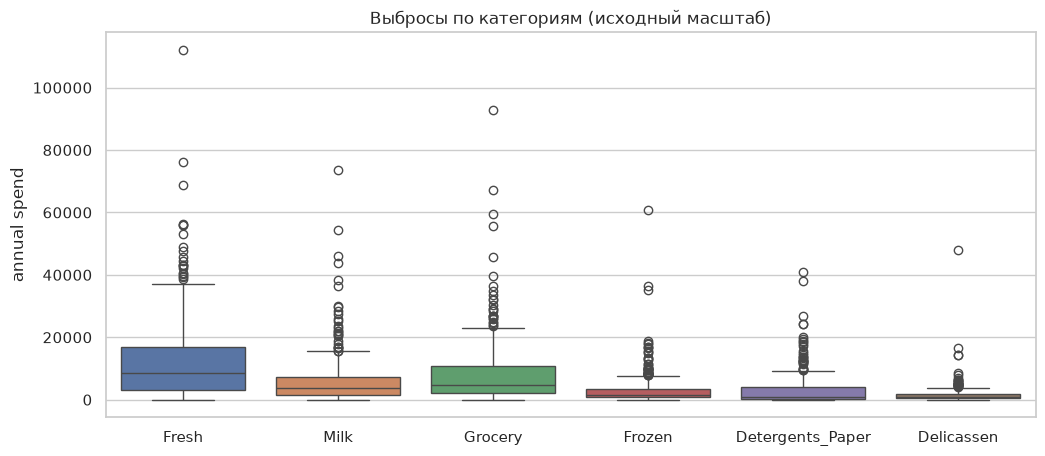

In [7]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum()

out = pd.DataFrame({
    "n_outliers": [iqr_outliers(df[c]) for c in spend_cols],
}, index=spend_cols)
out["pct"] = (out["n_outliers"] / len(df) * 100).round(1)
print(out.sort_values("n_outliers", ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df[spend_cols], ax=ax)
ax.set_title("Выбросы по категориям (исходный масштаб)")
ax.set_ylabel("annual spend")
plt.show()

Выбросы есть во **всех** категориях (особенно `Delicassen` и `Frozen`).
Удалять их не будем: это реальные крупные клиенты, и именно они формируют
сегменты. Но о них надо помнить — они влияют на PCA.

### 1.5 Матрица корреляций

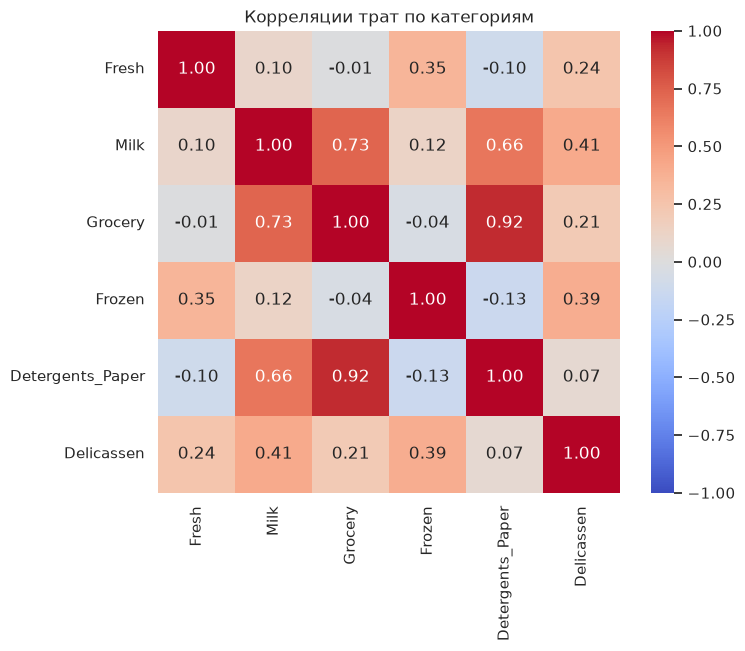

Топ положительных корреляций:
Grocery           Detergents_Paper   0.9
                  Milk               0.7
Detergents_Paper  Milk               0.7
dtype: float64


In [8]:
corr = df[spend_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, vmin=-1, vmax=1, ax=ax)
ax.set_title("Корреляции трат по категориям")
plt.show()

# Самые сильные пары
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
         .stack().sort_values(ascending=False))
print("Топ положительных корреляций:")
print(pairs[pairs > 0].drop_duplicates().head(3))

**Сильнее всего связаны `Grocery`–`Detergents_Paper` (~0.92) и `Grocery`–`Milk`.**
Это «магазинный» паттерн трат — именно он отделит розницу от HoReCa.
`Fresh` и `Frozen` почти ни с чем не коррелируют — отдельная «свежая/заморозка» ось.

### 1.6 Приведение к одному масштабу (StandardScaler)
Стандартизируем 6 числовых признаков: среднее → 0, стандартное отклонение → 1.
Категориальные `Channel`/`Region` не масштабируем.

In [9]:
scaler = StandardScaler()
X = df[spend_cols].values
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=spend_cols)
print("После StandardScaler:")
print(df_scaled.describe().T[["mean", "std", "min", "max"]].round(2))
print("\nГотово: X_scaled (440 x 6) — вход для PCA и кластеризации на Шаге 2+.")

После StandardScaler:
                  mean  std  min  max
Fresh             -0.0  1.0 -0.9  7.9
Milk               0.0  1.0 -0.8  9.2
Grocery           -0.0  1.0 -0.8  8.9
Frozen             0.0  1.0 -0.6 11.9
Detergents_Paper   0.0  1.0 -0.6  8.0
Delicassen        -0.0  1.0 -0.5 16.5

Готово: X_scaled (440 x 6) — вход для PCA и кластеризации на Шаге 2+.


---
## Находка, которая удивила (для выступления)

**Корреляция `Grocery`–`Detergents_Paper` ≈ 0.92.** Шесть «независимых» категорий
трат на деле не независимы: бакалея и бытовая химия/бумага почти линейно связаны.
Это и есть скрытая ось «розничный магазин», ради обнаружения которой нужен PCA —
две сильно скоррелированные категории фактически несут одну компоненту информации,
а значит шесть измерений реально сжимаются в заметно меньшее число.

---
## Шаг 2. Кластеризация (KMeans)

Меток нет — структуру ищем сами на масштабированных данных `X_scaled`.
Число кластеров `k` не угадываем, а выбираем по двум диагностикам:

- **Метод локтя** — `inertia` (сумма квадратов расстояний до центров) от `k`.
  Ищем «излом», после которого добавление кластеров почти не уменьшает inertia.
- **Коэффициент силуэта** — насколько объекты ближе к своему кластеру, чем к
  соседнему (от −1 до 1, больше = лучше). Берём `k` с максимумом.

Проверяем не один `k`, а диапазон, и сверяем обе метрики.

In [10]:
# KMeans, silhouette_score, silhouette_samples импортированы в начале ноутбука
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({"k": list(k_range),
                        "inertia": inertias,
                        "silhouette": silhouettes})
print(results.to_string(index=False))

 k  inertia  silhouette
 2  1,956.1         0.5
 3  1,608.4         0.5
 4  1,317.8         0.3
 5  1,058.8         0.4
 6    915.7         0.4
 7    825.4         0.3
 8    737.4         0.3
 9    661.4         0.3
10    605.9         0.3


### 2.1 Метод локтя и силуэт

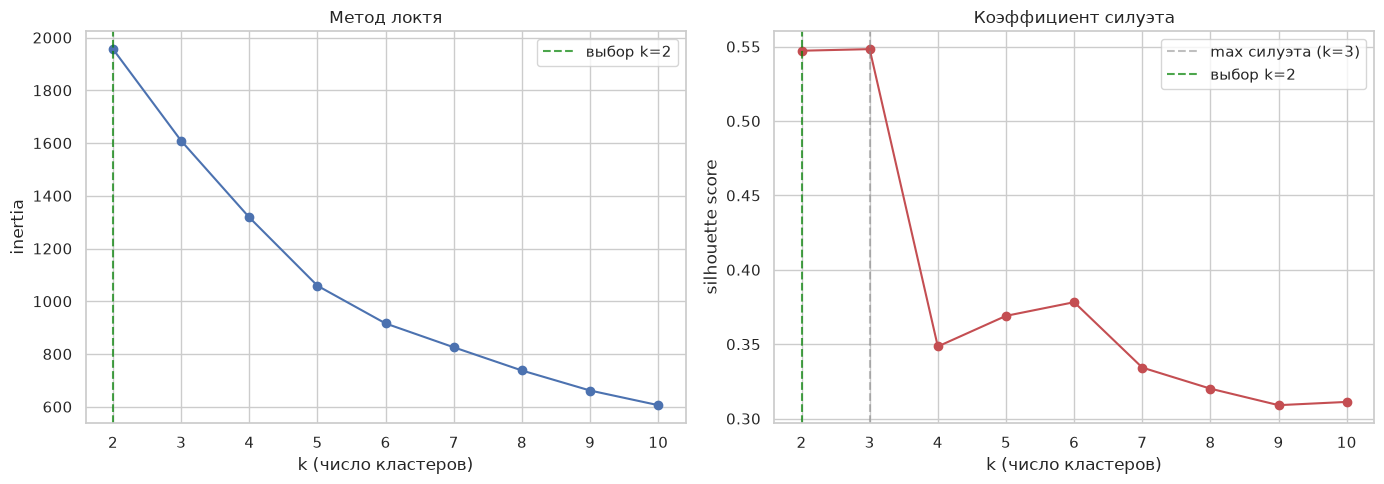

Формальный максимум силуэта при k = 3 (score = 0.548); silhouette(k=2) = 0.547 — практически столько же


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, "o-", color="#4C72B0")
ax1.set_title("Метод локтя")
ax1.set_xlabel("k (число кластеров)")
ax1.set_ylabel("inertia")
ax1.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax1.legend()

ax2.plot(list(k_range), silhouettes, "o-", color="#C44E52")
ax2.set_title("Коэффициент силуэта")
ax2.set_xlabel("k (число кластеров)")
ax2.set_ylabel("silhouette score")
best_k = int(results.loc[results.silhouette.idxmax(), "k"])
ax2.axvline(best_k, color="grey", ls="--", alpha=0.5,
            label=f"max силуэта (k={best_k})")
ax2.axvline(2, color="green", ls="--", alpha=0.7, label="выбор k=2")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"Формальный максимум силуэта при k = {best_k} "
      f"(score = {results.silhouette.max():.3f}); "
      f"silhouette(k=2) = {results.silhouette.iloc[0]:.3f} — практически столько же")

### 2.2 Проверяем соседние k (не верим первому на слово)

Силуэт максимален при малом `k`, но это часто разрезает данные на пару грубых
половин. Сравним кандидатов 2–4 не только по среднему силуэту, но и по балансу
размеров кластеров и по доле объектов с **отрицательным** силуэтом (плохо
отнесённые точки).

In [12]:
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sample_sil = silhouette_samples(X_scaled, labels)
    sizes = np.bincount(labels)
    neg = (sample_sil < 0).mean() * 100
    print(f"k={k}: silhouette={sil:.3f} | "
          f"размеры кластеров={sizes.tolist()} | "
          f"доля отрицательного силуэта={neg:.1f}%")

k=2: silhouette=0.547 | размеры кластеров=[389, 51] | доля отрицательного силуэта=4.1%
k=3: silhouette=0.548 | размеры кластеров=[45, 393, 2] | доля отрицательного силуэта=2.3%


k=4: silhouette=0.348 | размеры кластеров=[110, 315, 10, 5] | доля отрицательного силуэта=2.3%


### 2.3 Выбор k и финальная модель

**Выбираем k = 2.**

Здесь как раз важно «не верить первому k на слово». Формально максимум силуэта
приходится на k = 3 (0.548), но у k = 2 он практически такой же (0.547) — разница
0.001, в пределах шума. А проверка соседнего k = 3 показывает, **за счёт чего**
он выигрывает эту тысячную:

- При k = 3 размеры кластеров `[45, 393, 2]` — третий кластер это **всего 2
  клиента**. Это экстремальные выбросы (гигантские траты на `Frozen`/`Delicassen`),
  а не настоящая структура. Силуэт чуть подрос, потому что два далёких выброса
  идеально «лежат» в собственном микрокластере. Такой кластер не обобщается.
- При k = 2 разбиение `[389, 51]` — содержательное и устойчивое, ровно в духе
  поставленной интерпретации **HoReCa vs Retail**.
- k = 4 уже резко роняет силуэт (0.35) — лишнее дробление.
- Локоть пологий (резкого излома нет), что согласуется с малым числом реальных
  кластеров.

Вывод: тысячная доля силуэта в пользу k = 3 — артефакт двух выбросов, поэтому
берём **k = 2** как осмысленный и воспроизводимый выбор.

In [13]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Размеры кластеров:")
print(df["cluster"].value_counts().sort_index(), "\n")

# Средние траты по кластерам в ИСХОДНОМ масштабе (для интерпретации)
profile = df.groupby("cluster")[spend_cols].mean().round(0)
print("Средние годовые траты по кластерам (исходный масштаб):")
print(profile.to_string())

Размеры кластеров:
cluster
0    389
1     51
Name: count, dtype: int64 

Средние годовые траты по кластерам (исходный масштаб):
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0       12,157.0  4,028.0  5,403.0 3,066.0           1,668.0     1,257.0
1       10,803.0 19,282.0 27,390.0 3,117.0          12,140.0     3,569.0


Кластер x Channel:
         HoReCa (1)  Retail (2)
cluster                        
0               293          96
1                 5          46


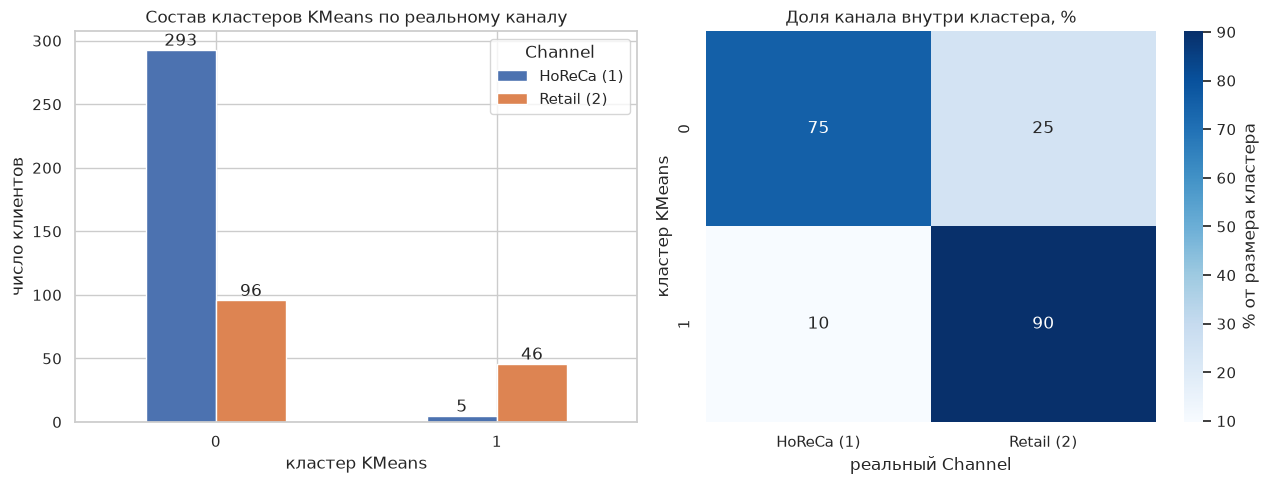

In [14]:
# Сверяем кластеры с реальным Channel (1=HoReCa, 2=Retail) — он не участвовал в обучении
ct = pd.crosstab(df["cluster"], df["Channel"])
ct.columns = ["HoReCa (1)", "Retail (2)"]
print("Кластер x Channel:")
print(ct)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (1) Сгруппированные столбцы: сколько HoReCa / Retail попало в каждый кластер
ct.plot(kind="bar", ax=ax1, color=["#4C72B0", "#DD8452"], edgecolor="white")
ax1.set_title("Состав кластеров KMeans по реальному каналу")
ax1.set_xlabel("кластер KMeans")
ax1.set_ylabel("число клиентов")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(title="Channel")
for cont in ax1.containers:
    ax1.bar_label(cont)

# (2) Тепловая карта: какая доля канала внутри каждого кластера (по строкам, %)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% от размера кластера"}, ax=ax2)
ax2.set_title("Доля канала внутри кластера, %")
ax2.set_xlabel("реальный Channel")
ax2.set_ylabel("кластер KMeans")

plt.tight_layout()
plt.show()

**Интерпретация кластеров** (по средним тратам и сверке с `Channel`):
KMeans без меток в основном воспроизводит разделение **HoReCa vs Retail**.
Маленький кластер — клиенты с высокими `Grocery`/`Milk`/`Detergents_Paper`
(розничный «магазинный» паттерн), большой кластер тяготеет к `Fresh`/`Frozen`
(HoReCa). Сверка с не участвовавшим в обучении `Channel` подтверждает: разбиение
во многом совпадает с реальным каналом продаж (хотя и не идеально — часть Retail
попадает в HoReCa-кластер). Финальные метки `df["cluster"]` сохранены для
визуализации через PCA на Шаге 3.